# Implementation of own SGD in Linear Regression

In [1]:
from sklearn.datasets import load_boston
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import load_boston
from random import seed
from random import randrange
from csv import reader
from math import sqrt
from sklearn import preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from sklearn.linear_model import SGDRegressor
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_boston
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
scaler = StandardScaler()
boston = load_boston()

In [3]:
import pandas as pd
bos = pd.DataFrame(boston.data)
print(bos.head())

        0     1     2    3      4      5     6       7    8      9     10  \
0  0.00632  18.0  2.31  0.0  0.538  6.575  65.2  4.0900  1.0  296.0  15.3   
1  0.02731   0.0  7.07  0.0  0.469  6.421  78.9  4.9671  2.0  242.0  17.8   
2  0.02729   0.0  7.07  0.0  0.469  7.185  61.1  4.9671  2.0  242.0  17.8   
3  0.03237   0.0  2.18  0.0  0.458  6.998  45.8  6.0622  3.0  222.0  18.7   
4  0.06905   0.0  2.18  0.0  0.458  7.147  54.2  6.0622  3.0  222.0  18.7   

       11    12  
0  396.90  4.98  
1  396.90  9.14  
2  392.83  4.03  
3  394.63  2.94  
4  396.90  5.33  


In [4]:
bos['PRICE'] = boston.target

X = bos.drop('PRICE', axis = 1).as_matrix()
Y = bos['PRICE'][:,np.newaxis]

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.33, random_state = 5)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(339, 13)
(167, 13)
(339, 1)
(167, 1)


### Standerized data

In [6]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

In [7]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(339, 13)
(167, 13)
(339, 1)
(167, 1)


In [8]:
W_vector = np.random.normal(0,1,13)[:,np.newaxis]
b_scaler = np.random.normal(0,1,1)
print(W_vector.shape)

(13, 1)


In [9]:
def gradient_descendent(X,Y):
    w_curr = W_vector
    b_curr = b_scaler
    n = len(X)
    K = range(0,1000)
    step_size  = 0.05
    for i in tqdm(K):
        y_predicted = np.matmul(X , w_curr) + b_curr
        cost = mean_squared_error(y_predicted,Y)
        wd = -(2/n) * (X *(Y - y_predicted))
        wd = np.sum(wd,axis=0)[:,np.newaxis]
        bd = -(2/n) * (Y - y_predicted)
        bd = np.sum(bd,axis=0)[:,np.newaxis]
        w_curr = w_curr - step_size * wd
        b_curr = b_curr - step_size * bd
    return w_curr , b_curr

In [10]:
optimal_w , optimal_b = gradient_descendent(X_train,Y_train)

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1254.52it/s]


In [11]:
optimal_b

array([[22.53716814]])

In [12]:
optimal_w

array([[-1.31136409],
       [ 0.86095895],
       [-0.17054111],
       [ 0.19007871],
       [-1.4863879 ],
       [ 2.79193345],
       [-0.3281048 ],
       [-2.77280221],
       [ 2.9646082 ],
       [-2.26044795],
       [-2.13347738],
       [ 1.05825629],
       [-3.33450373]])

In [13]:
def predict_SGD(X , opt_W,opt_B):
    pred_y = np.matmul(X , opt_W) + opt_B
    return pred_y

In [14]:
def predict_SGD(X , opt_W,opt_B):
    pred_y = np.matmul(X , opt_W) + opt_B
    return pred_y

In [15]:
Y_pred = predict_SGD(X_test,optimal_w,optimal_b)

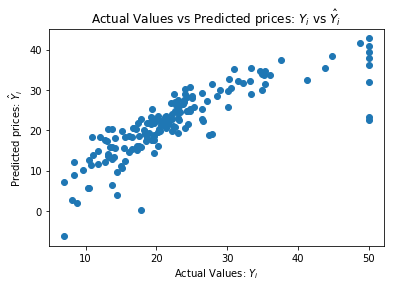

In [16]:
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Values: $Y_i$")
plt.ylabel("Predicted prices: $\hat{Y}_i$")
plt.title("Actual Values vs Predicted prices: $Y_i$ vs $\hat{Y}_i$")
plt.show()

In [17]:
SGD = mean_squared_error(Y_pred,Y_test)
print(SGD)

28.527959149358285


## Observation 
* Mean Squared Error in Implementation of SGD without Sklean is 28.52

# Implementation of SGD using Sklearn

In [18]:
clf = SGDRegressor(penalty='l1')
clf.fit(X_train, Y_train)
Y_pred = clf.predict(X_test)

In [19]:
print(clf.coef_)
print(clf.intercept_)

[-0.90975012  0.48795643 -0.55796378  0.27209997 -0.36717451  3.19110782
 -0.3541688  -1.6232345   0.59954514 -0.51500311 -1.84842272  0.89262396
 -3.00587247]
[21.89366872]


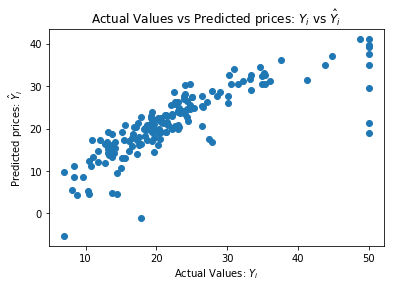

In [20]:
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Values: $Y_i$")
plt.ylabel("Predicted prices: $\hat{Y}_i$")
plt.title("Actual Values vs Predicted prices: $Y_i$ vs $\hat{Y}_i$")
plt.show()

In [21]:
SGD_Sklearn = mean_squared_error(Y_pred,Y_test)
print(SGD_Sklearn)

31.18221608124086


## Observation 
* Mean Squared Error in Implementation of SGD without Sklean is 30.59

In [22]:
# http://zetcode.com/python/prettytable/
from prettytable import PrettyTable
x = PrettyTable()
x.field_names = ["Implentation","Wieght","Intercept","MSE"]
x.add_row(["Custom",clf.coef_, clf.intercept_,SGD])
x.add_row(["SKlearn",optimal_w.T,optimal_b ,SGD_Sklearn])
print(x)

+--------------+---------------------------------------------------------------------------+-----------------+--------------------+
| Implentation |                                   Wieght                                  |    Intercept    |        MSE         |
+--------------+---------------------------------------------------------------------------+-----------------+--------------------+
|    Custom    |  [-0.90975012  0.48795643 -0.55796378  0.27209997 -0.36717451  3.19110782 |  [21.89366872]  | 28.527959149358285 |
|              |   -0.3541688  -1.6232345   0.59954514 -0.51500311 -1.84842272  0.89262396 |                 |                    |
|              |                                -3.00587247]                               |                 |                    |
|   SKlearn    | [[-1.31136409  0.86095895 -0.17054111  0.19007871 -1.4863879   2.79193345 | [[22.53716814]] | 31.18221608124086  |
|              |   -0.3281048  -2.77280221  2.9646082  -2.26044795 -2.133477